# Wind-blown snow training sandbox
- Known inputs (conditioning): wind_speed/direction, air_temperature, relative_humidity, air_pressure, solar_radiation, snow_surface_temperature, turbulence_intensity, friction_velocity, stability_flag, quality/data_source dummies, optional spectra as covariates.
- Targets to predict: snow_mass_flux_kg_m2_s (primary), snow_number_flux_m2_s (secondary), optionally individual spectral flux bins.
- Derived cues: wind_snow_coupling, threshold_exceedance, radiation/heat flux proxies can stay as inputs.
- PINN hook: add physics penalty that enforces coupling between wind speed, friction velocity, stability, and flux (placeholder below).


In [14]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from pathlib import Path
import sys
sys.path.append(str(Path('src').resolve()))
from src.main.snow_models import SnowLSTM

torch.manual_seed(0)


In [15]:
data_path = Path('data/synthetic/windblown_snow_sample.csv')
window_size = 24  # past steps used for conditioning
horizon = 6       # steps to forecast
train_ratio = 0.8

KNOWN_COLS = [
    'wind_speed_ms', 'wind_direction_deg', 'air_temperature_c', 'relative_humidity',
    'air_pressure_pa', 'solar_radiation_wm2', 'snow_surface_temperature_c',
    'turbulence_intensity', 'friction_velocity_ms', 'ri_bulk',
    'wind_snow_coupling', 'threshold_exceedance',
    'net_radiation_est', 'sensible_heat_flux_est', 'latent_heat_flux_est',
]
TARGET_COLS = ['snow_mass_flux_kg_m2_s', 'snow_number_flux_m2_s']

# Spectrum columns (can be appended to known inputs or treated as extra targets)
SPECTRUM_COLS = []


In [16]:
df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Identify spectrum columns dynamically
SPECTRUM_COLS = [c for c in df.columns if c.startswith(('size_bin_', 'velocity_bin_'))]

# Optionally include spectra as covariates
use_spectra_as_known = True
if use_spectra_as_known:
    KNOWN = KNOWN_COLS + SPECTRUM_COLS
else:
    KNOWN = KNOWN_COLS

# Encode categorical flags
df = pd.get_dummies(df, columns=['stability_flag', 'quality_flag', 'data_source'], drop_first=True)
KNOWN += [c for c in df.columns if c.startswith(('stability_flag_', 'quality_flag_', 'data_source_'))]

# Ensure targets exist
for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f'Missing target column: {col}')

feature_df = df.sort_values('timestamp').reset_index(drop=True)
features = feature_df[KNOWN].to_numpy(dtype=np.float32)
targets = feature_df[TARGET_COLS].to_numpy(dtype=np.float32)

# Normalize features
feat_mean = features.mean(axis=0, keepdims=True)
feat_std = features.std(axis=0, keepdims=True) + 1e-6
features = (features - feat_mean) / feat_std

print('features shape', features.shape, 'targets shape', targets.shape)


features shape (10000, 37) targets shape (10000, 2)


In [17]:
class SnowDataset(torch.utils.data.Dataset):
    def __init__(self, feats: np.ndarray, tgs: np.ndarray, window: int, horizon: int):
        self.feats = feats
        self.tgs = tgs
        self.window = window
        self.horizon = horizon
        self.max_idx = len(self.feats) - window - horizon
    def __len__(self):
        return max(self.max_idx, 0)
    def __getitem__(self, idx):
        x = self.feats[idx: idx + self.window]
        y = self.tgs[idx + self.window: idx + self.window + self.horizon]
        return torch.from_numpy(x), torch.from_numpy(y)

split = int(len(features) * train_ratio)
train_ds = SnowDataset(features[:split], targets[:split], window_size, horizon)
val_ds = SnowDataset(features[split - window_size:], targets[split - window_size:], window_size, horizon)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, shuffle=False)

print('train batches', len(train_loader), 'val batches', len(val_loader))


train batches 125 val batches 32


In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SnowLSTM(input_dim=len(KNOWN), horizon=horizon, target_dim=len(TARGET_COLS)).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [ ]:
def physics_penalty(batch_x: torch.Tensor, batch_y_hat: torch.Tensor) -> torch.Tensor:
    # Placeholder PINN penalty: encourage higher flux when wind speed exceeds threshold
    wind_idx = KNOWN.index('wind_speed_ms')
    wind = batch_x[:, :, wind_idx]
    mask = (wind[:, -1] > 7.5).float()
    flux_hat = batch_y_hat[:, :, 0].mean(dim=1)
    penalty = ((mask - torch.sigmoid(flux_hat * 1e4)) ** 2).mean()
    return penalty

def run_epoch(loader, train: bool = True):
    total = 0.0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train:
            optim.zero_grad()
        preds = model(xb)
        mse = loss_fn(preds, yb)
        pin = physics_penalty(xb, preds)
        loss = mse + 0.1 * pin
        if train:
            loss.backward()
            optim.step()
        total += loss.item() * len(xb)
    return total / max(len(loader.dataset), 1)

for epoch in range(10):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    print(f'Epoch {epoch}: train {train_loss:.4f} val {val_loss:.4f}')


Epoch 0: train 5722.9947 val 5561.7010
Epoch 1: train 5070.2119 val 5099.9833
Epoch 2: train 4748.4045 val 4857.3051
Epoch 3: train 4595.0891 val 4745.7352
Epoch 4: train 4532.6596 val 4699.3621
Epoch 5: train 4509.5263 val 4681.9399
Epoch 6: train 4502.6607 val 4675.4488
Epoch 7: train 4500.8408 val 4672.9332
Epoch 8: train 4500.4271 val 4672.0924
Epoch 9: train 4500.6608 val 4671.7896
Epoch 10: train 4500.3930 val 4671.6375
Epoch 11: train 4500.3678 val 4671.3905
Epoch 12: train 4500.3924 val 4671.5784
Epoch 13: train 4500.4512 val 4671.4816
Epoch 14: train 4501.8243 val 4672.0479
Epoch 15: train 4500.5311 val 4671.4158
Epoch 16: train 4500.3830 val 4671.2932
Epoch 17: train 4500.4252 val 4671.6371
Epoch 18: train 4500.3704 val 4671.2366
Epoch 19: train 4500.4003 val 4671.6753


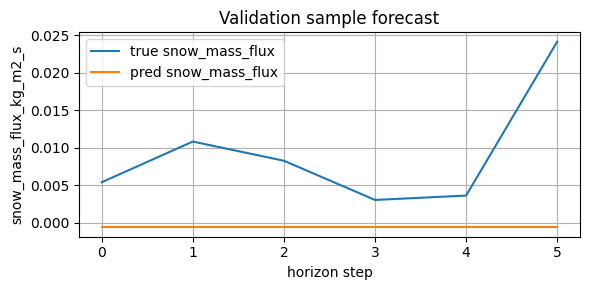

In [20]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    yb = yb.to(device)
    preds = model(xb)

pred = preds[0, :, 0].cpu().numpy()
true = yb[0, :, 0].cpu().numpy()
steps = range(len(pred))

plt.figure(figsize=(6, 3))
plt.plot(steps, true, label='true snow_mass_flux')
plt.plot(steps, pred, label='pred snow_mass_flux')
plt.xlabel('horizon step')
plt.ylabel('snow_mass_flux_kg_m2_s')
plt.title('Validation sample forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
